# Amazon Product Reviews - Data Visualization

## Project Objective

The objective of this project is to transform Amazon product review data into meaningful visualizations that help understand customer behavior, product performance, and business trends. Using Python, Matplotlib, and Seaborn, the project focuses on creating clear and informative charts that support data-driven decision-making.

In [48]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

## Load Dataset

In [49]:
df = pd.read_csv(
    "../Data/amazon_reviews.csv",
    sep="\t",
    low_memory=False
)

## Dataset Overview

Before creating visualizations, let's understand the structure and contents of the dataset. This helps verify that the data has been loaded correctly and is ready for visualization.

In [50]:
df = pd.read_csv(
    "../Data/amazon_reviews.csv",
    sep="\t",
    low_memory=False
)

In [51]:
df.shape

(34626, 12)

In [52]:
df.columns.tolist()

['id',
 'name',
 'brand',
 'categories',
 'manufacturer',
 'reviews.date',
 'reviews.doRecommend',
 'reviews.numHelpful',
 'reviews.rating',
 'reviews.text',
 'reviews.title',
 'reviews.username']

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34626 entries, 0 to 34625
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   id                   34626 non-null  object
 1   name                 34626 non-null  object
 2   brand                34626 non-null  object
 3   categories           34626 non-null  object
 4   manufacturer         34626 non-null  object
 5   reviews.date         34537 non-null  object
 6   reviews.doRecommend  34626 non-null  bool  
 7   reviews.numHelpful   34626 non-null  int64 
 8   reviews.rating       34626 non-null  int64 
 9   reviews.text         34626 non-null  object
 10  reviews.title        34626 non-null  object
 11  reviews.username     34626 non-null  object
dtypes: bool(1), int64(2), object(9)
memory usage: 2.9+ MB


In [54]:
df.head()

,id,name,brand,categories,manufacturer,reviews.date,reviews.doRecommend,reviews.numHelpful,reviews.rating,reviews.text,reviews.title,reviews.username
0,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",Amazon,2017-01-13 00:00:00+00:00,True,0,5,This product so far has not disappointed. My c...,Kindle,Adapter
1,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",Amazon,2017-01-13 00:00:00+00:00,True,0,5,great for beginner or experienced person. Boug...,very fast,truman
2,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",Amazon,2017-01-13 00:00:00+00:00,True,0,5,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.,DaveZ
3,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",Amazon,2017-01-13 00:00:00+00:00,True,0,4,I've had my Fire HD 8 two weeks now and I love...,Good!!!,Shacks
4,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",Amazon,2017-01-12 00:00:00+00:00,True,0,5,I bought this for my grand daughter when she c...,Fantastic Tablet for kids,explore42


# Visualization 1: Customer Rating Distribution

This chart shows how customers rated Amazon products. It helps us understand the overall satisfaction level of customers.

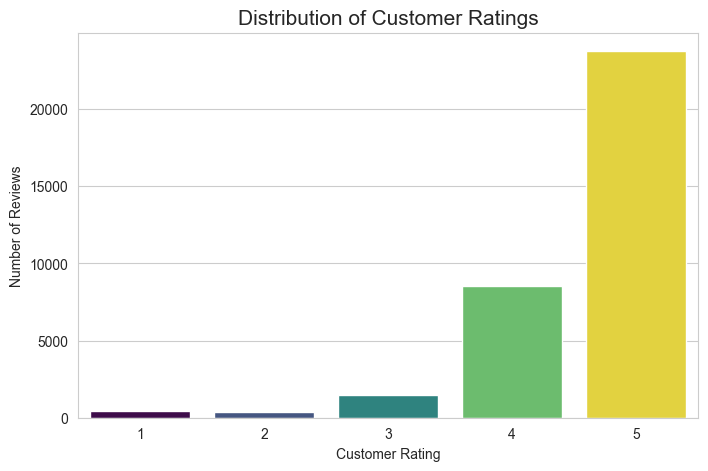

In [55]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="reviews.rating",
    hue="reviews.rating",
    palette="viridis",
    legend=False
)

plt.title("Distribution of Customer Ratings", fontsize=15)
plt.xlabel("Customer Rating")
plt.ylabel("Number of Reviews")

plt.savefig(
    "../Images/customer_rating_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 📌 Insight

- The majority of customer ratings are **4-star and 5-star**.
- This indicates a high level of customer satisfaction.
- Very few customers gave ratings below **3**, suggesting that most Amazon products receive positive feedback.

# Visualization 2: Recommendation Distribution

This chart shows whether customers recommend the product after purchasing it.

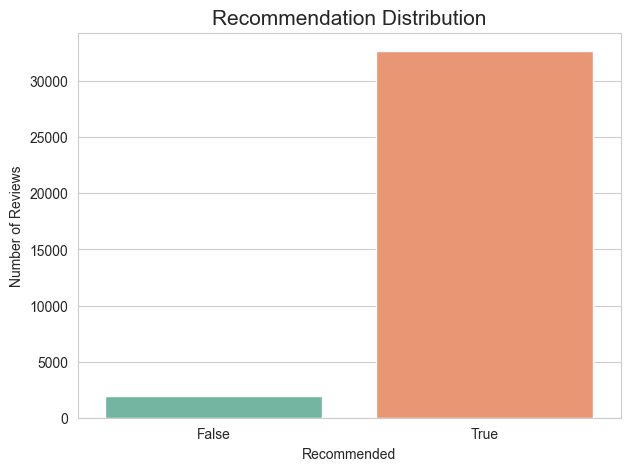

In [56]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="reviews.doRecommend",
    hue="reviews.doRecommend",
    palette="Set2",
    legend=False
)

plt.title("Recommendation Distribution", fontsize=15)
plt.xlabel("Recommended")
plt.ylabel("Number of Reviews")

plt.savefig(
    "../Images/recommendation_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 📌 Insight

- Most customers recommended the products they purchased.
- A high recommendation rate reflects strong customer trust and satisfaction.
- Only a small proportion of customers chose not to recommend the product.

# Visualization 3: Top 10 Brands by Number of Reviews

This visualization highlights the brands that received the highest number of customer reviews.

C:\Users\Mohit shrivastav\AppData\Local\Temp\ipykernel_6912\2568949139.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


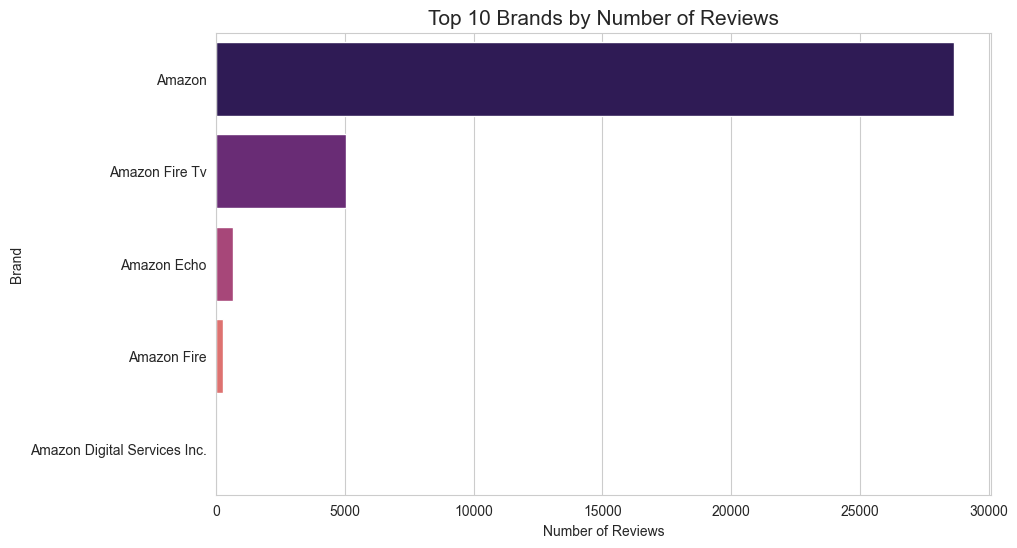

In [57]:
plt.figure(figsize=(10,6))

top_brands = df["brand"].value_counts().head(10)

sns.barplot(
    x=top_brands.values,
    y=top_brands.index,
    palette="magma"
)

plt.title("Top 10 Brands by Number of Reviews", fontsize=15)
plt.xlabel("Number of Reviews")
plt.ylabel("Brand")

plt.savefig(
    "../Images/top_brands.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 📌 Insight

- Amazon dominates the review count, indicating a strong presence in the dataset.
- Other brands have significantly fewer reviews in comparison.
- High review counts may indicate greater customer engagement and product popularity.

# Visualization 4: Top 10 Product Categories

This visualization shows the product categories with the highest number of customer reviews.

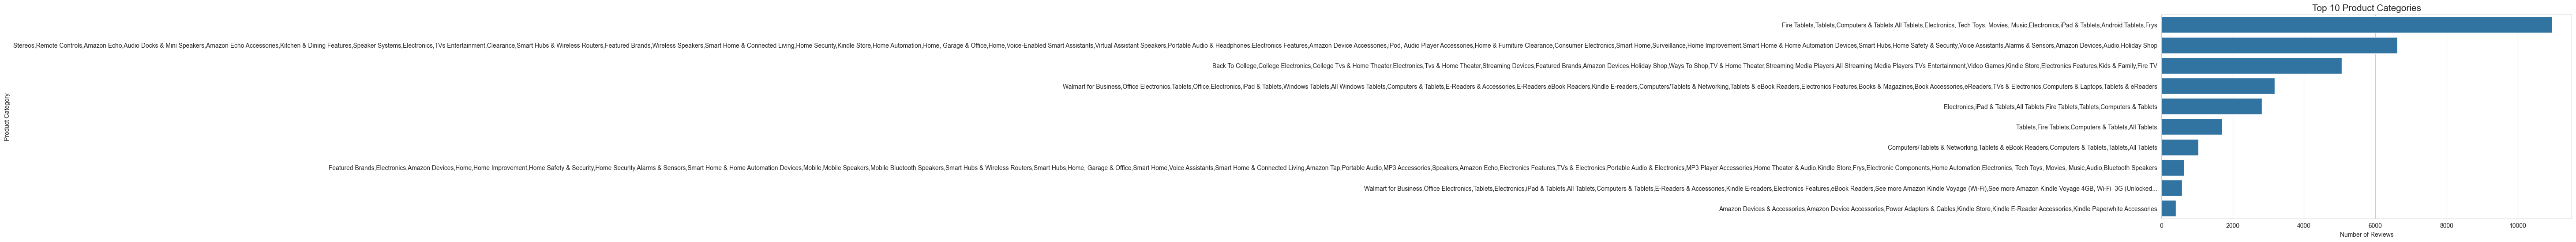

In [58]:
plt.figure(figsize=(12,6))

top_categories = df["categories"].value_counts().head(10)

sns.barplot(
    x=top_categories.values,
    y=top_categories.index
)

plt.title("Top 10 Product Categories", fontsize=15)
plt.xlabel("Number of Reviews")
plt.ylabel("Product Category")

plt.savefig(
    "../Images/top_categories.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 📌 Insight

- A few product categories dominate the review count.
- These categories represent the most popular product segments in the dataset.
- Businesses can prioritize these categories for marketing and inventory planning.

# Visualization 5: Average Rating by Brand

This chart compares the average customer rating of the top reviewed brands.

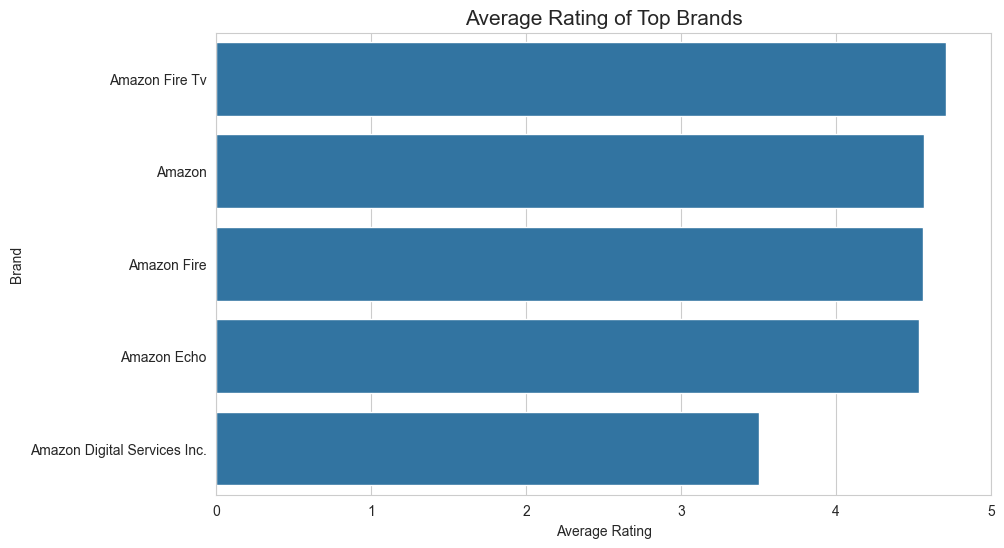

In [59]:
top_brands = df["brand"].value_counts().head(10).index

brand_rating = (
    df[df["brand"].isin(top_brands)]
    .groupby("brand")["reviews.rating"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=brand_rating.values,
    y=brand_rating.index
)

plt.title("Average Rating of Top Brands", fontsize=15)
plt.xlabel("Average Rating")
plt.ylabel("Brand")

plt.xlim(0,5)

plt.savefig(
    "../Images/average_rating_by_brand.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 📌 Insight

- Most top brands maintain high average ratings.
- Comparing average ratings helps identify brands with stronger customer satisfaction.

In [60]:
df["review_length"] = df["reviews.text"].fillna("").str.len()

# Visualization 6: Review Length Distribution

This histogram illustrates the distribution of customer review lengths.

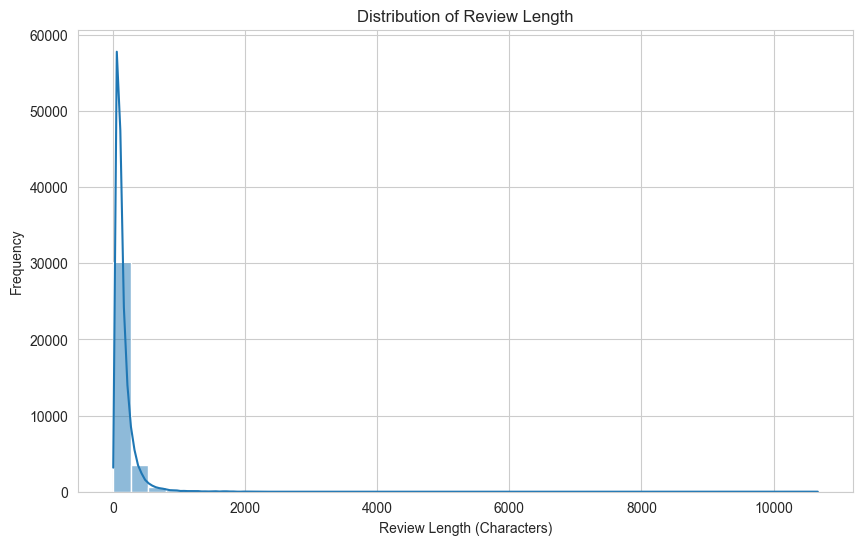

In [61]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["review_length"],
    bins=40,
    kde=True
)

plt.title("Distribution of Review Length")
plt.xlabel("Review Length (Characters)")
plt.ylabel("Frequency")

plt.savefig(
    "../Images/review_length_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 📌 Insight

- Most customers write relatively short reviews.
- A smaller number of customers provide detailed and lengthy feedback.

# Visualization 7: Rating vs Recommendation

This visualization compares customer ratings with whether they recommended the product.

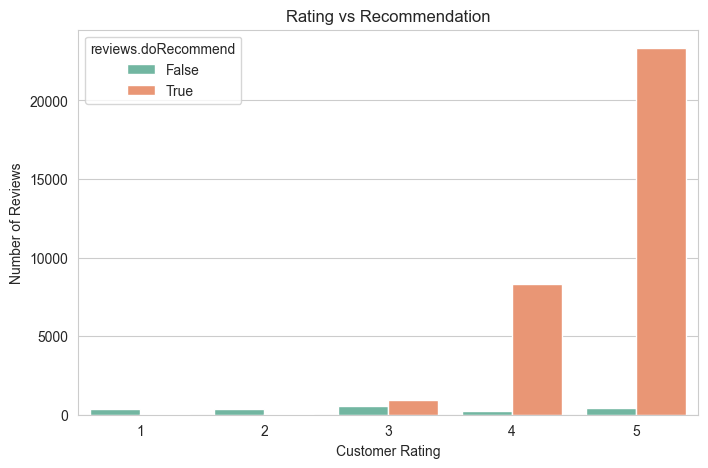

In [62]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="reviews.rating",
    hue="reviews.doRecommend",
    palette="Set2"
)

plt.title("Rating vs Recommendation")
plt.xlabel("Customer Rating")
plt.ylabel("Number of Reviews")

plt.savefig(
    "../Images/rating_vs_recommendation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 📌 Insight

- Customers who gave higher ratings were much more likely to recommend the product.
- Lower ratings are associated with fewer recommendations.

# Visualization 8: Rating vs Review Length

This box plot compares review lengths across different rating values.

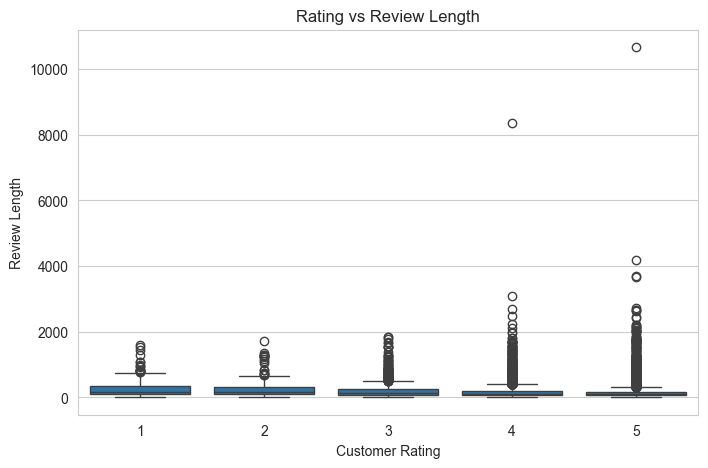

In [63]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="reviews.rating",
    y="review_length"
)

plt.title("Rating vs Review Length")
plt.xlabel("Customer Rating")
plt.ylabel("Review Length")

plt.savefig(
    "../Images/rating_vs_review_length.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 📌 Insight

- Customers giving lower ratings often write longer reviews.
- Positive reviews tend to be shorter and more concise.

# Visualization 9: Most Active Reviewers

This visualization highlights the users who contributed the highest number of product reviews.

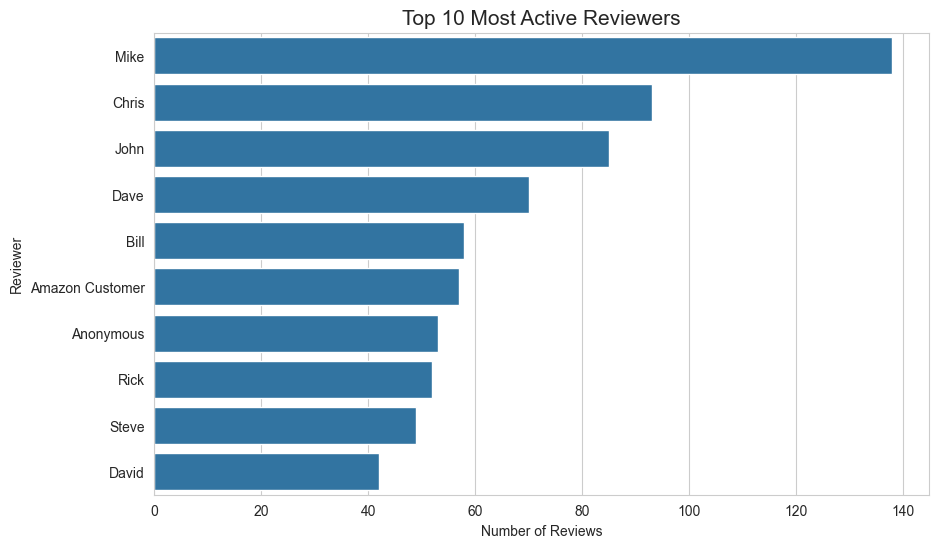

In [64]:
plt.figure(figsize=(10,6))

top_reviewers = df["reviews.username"].value_counts().head(10)

sns.barplot(
    x=top_reviewers.values,
    y=top_reviewers.index
)

plt.title("Top 10 Most Active Reviewers", fontsize=15)
plt.xlabel("Number of Reviews")
plt.ylabel("Reviewer")

plt.savefig(
    "../Images/top_reviewers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 📌 Insight

- A small number of users contribute a large number of reviews.
- Identifying active reviewers can help understand customer engagement and loyalty.

# Visualization 10: Correlation Heatmap

This heatmap displays the correlation between numerical variables in the dataset.

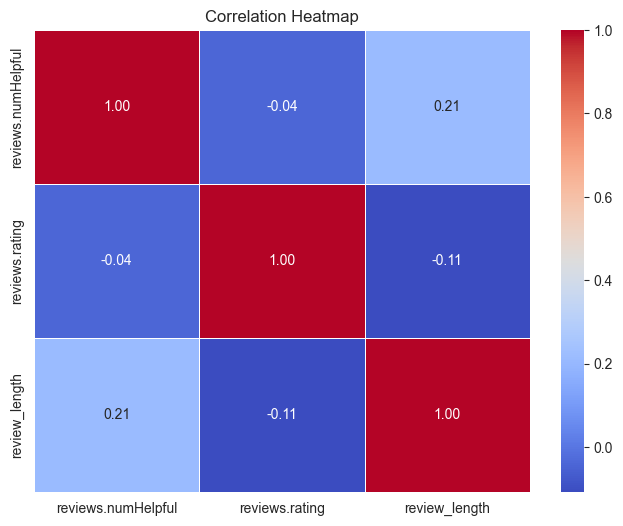

In [65]:
numeric_df = df.select_dtypes(include="number")

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.savefig(
    "../Images/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 📌 Insight

- Review ratings show only weak correlations with other numerical variables.
- Correlation analysis helps identify relationships between numerical features.

# Dashboard

This dashboard combines multiple visualizations to provide a quick overview of customer ratings, recommendations, brands, and review behavior.

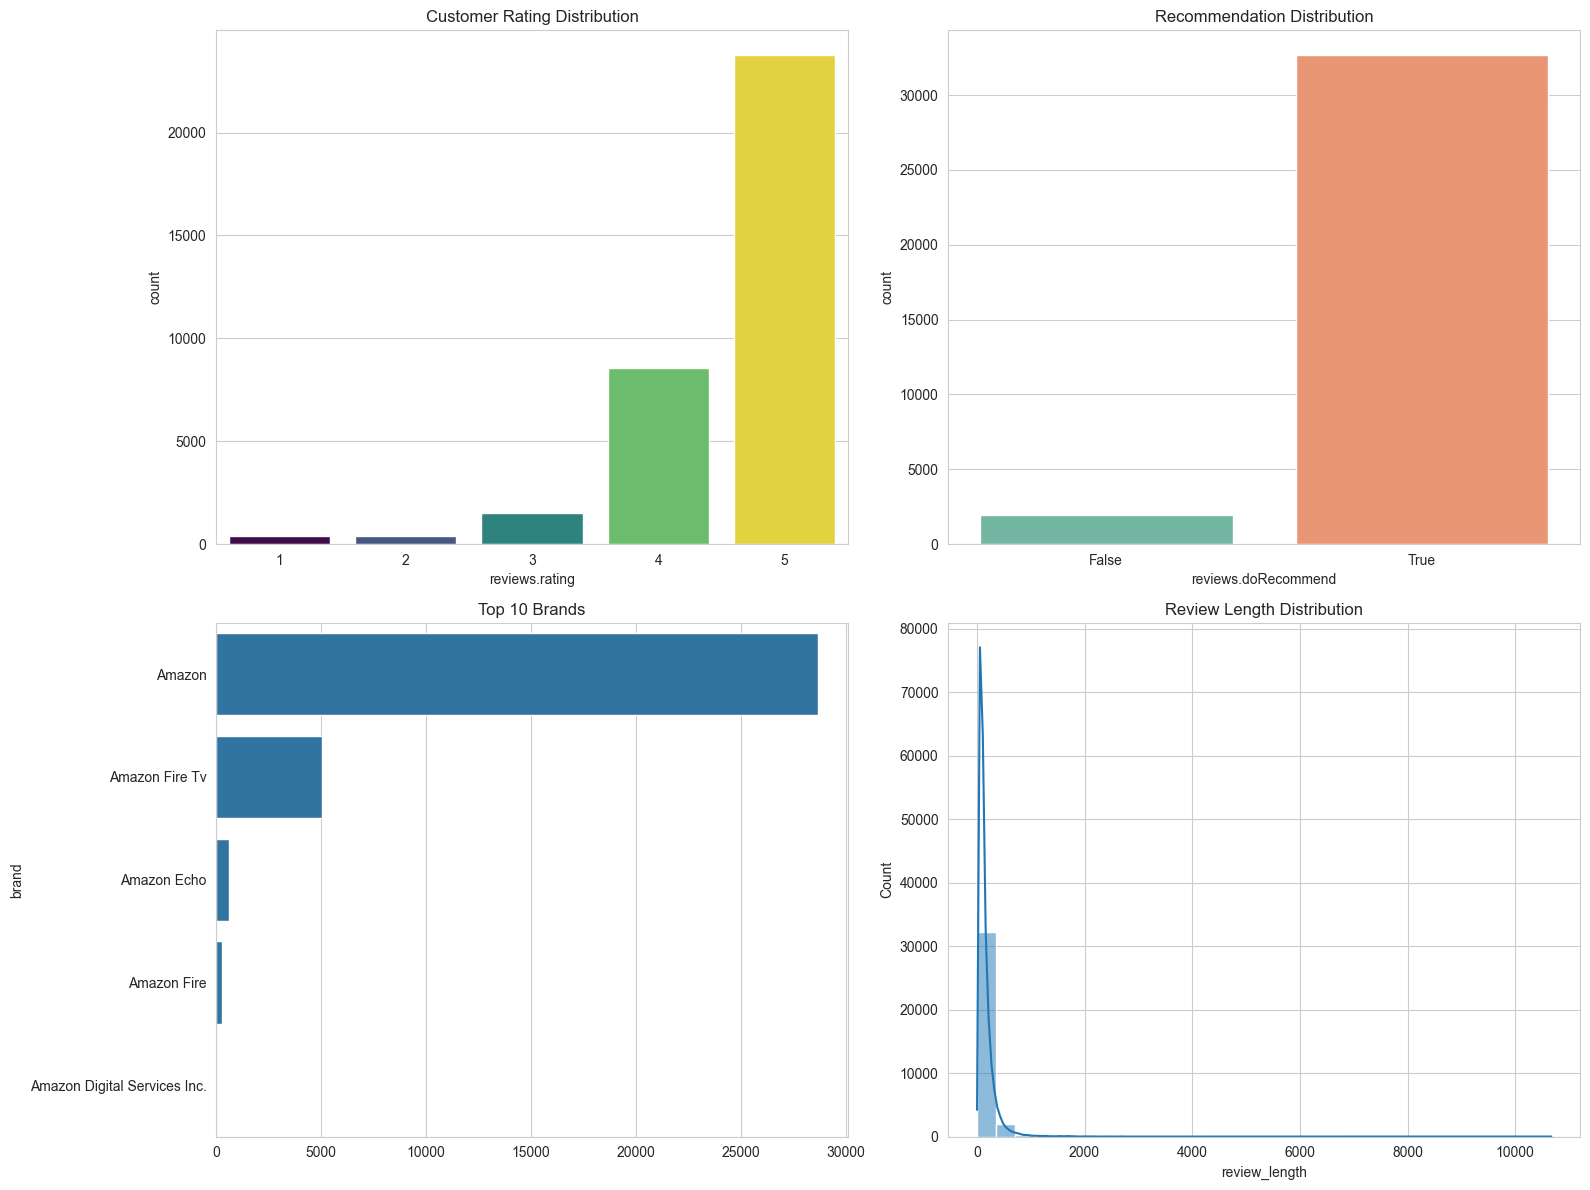

In [66]:
fig, axes = plt.subplots(2, 2, figsize=(16,12))

# 1 Rating Distribution
sns.countplot(
    data=df,
    x="reviews.rating",
    ax=axes[0,0],
    hue="reviews.rating",
    legend=False,
    palette="viridis"
)
axes[0,0].set_title("Customer Rating Distribution")

# 2 Recommendation Distribution
sns.countplot(
    data=df,
    x="reviews.doRecommend",
    ax=axes[0,1],
    hue="reviews.doRecommend",
    legend=False,
    palette="Set2"
)
axes[0,1].set_title("Recommendation Distribution")

# 3 Top Brands
top_brands = df["brand"].value_counts().head(10)

sns.barplot(
    x=top_brands.values,
    y=top_brands.index,
    ax=axes[1,0]
)
axes[1,0].set_title("Top 10 Brands")

# 4 Review Length
sns.histplot(
    df["review_length"],
    bins=30,
    kde=True,
    ax=axes[1,1]
)
axes[1,1].set_title("Review Length Distribution")

plt.tight_layout()

plt.savefig(
    "../Images/dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Business Story

The visualizations reveal that Amazon products generally receive highly positive customer feedback, with most reviews being 4 or 5 stars. Customers who are satisfied are also more likely to recommend the products. A few brands dominate customer engagement, indicating strong market presence. Review behavior suggests that dissatisfied customers often provide longer, more detailed feedback, while satisfied customers tend to leave shorter reviews. Overall, the analysis demonstrates how data visualization can transform raw customer review data into actionable business insights that support better decision-making.

# Conclusion

This project demonstrates how effective data visualization helps uncover meaningful patterns within Amazon product review data. By creating a variety of charts and a dashboard using Python, Pandas, Matplotlib, and Seaborn, customer behavior and product trends were presented in a clear and understandable manner. The project highlights the importance of visual storytelling in data analytics and supports data-driven decision-making.